## 7. Model : **Baseline Heterogeneous GNN**.

### Model / Train Block.

This block defines and trains the baseline heterogeneous graph neural network used as the first predictive model. After the earlier blocks cleaned the PrimeKG graph and prepared the link prediction splits, this section focuses on learning node representations and using them to predict whether a drug should connect to a disease through the **indication** relation.

The baseline model is a heterogeneous GNN built with **GraphSAGE-style message passing**. It uses the full heterogeneous graph structure from the training set and learns embeddings for each node type, which are then used to score candidate drug–disease pairs.

### Define the supervision relation and evaluation inputs

The model in this block is trained for one specific link prediction task:

- **source node type:** `drug`
- **relation type:** `indication`
- **destination node type:** `disease`

This relation triplet is stored in `SUP_EDGE_TYPE`, which matches the target relation.

The block also loads the validation and test supervision tensors:
- positive validation edges
- negative validation edges
- positive test edges
- negative test edges

These are moved to the same device as the model so they can be used during evaluation.

To support safe negative sampling during training, the code builds a complete set of known positive drug–disease pairs across training, validation, and test. This prevents the model from accidentally sampling a real positive edge as a negative example.

### Shared utility functions

Several helper functions are defined in this block because they are reused later in the notebook as well.

#### Negative edge sampling

The function `sample_negative_edges_bipartite(...)` generates random drug–disease pairs that do not exist in the known positive set. These sampled negatives are used during training so the model learns to distinguish true indication edges from false ones.

#### Loss functions

The block defines multiple loss-related functions:

- **`bce_loss`** applies binary cross-entropy to positive and negative scores
- **`bpr_loss`** applies a ranking-based loss that encourages positives to score higher than negatives
- **`combined_loss`** combines both objectives into one training loss

Using both classification-style and ranking-style supervision helps the model not only separate positives from negatives, but also rank true indications more highly.

#### Evaluation function

The function `evaluate_link_prediction(...)` computes the validation or test metrics for a given model. It evaluates the model on positive and negative edges and reports metrics such as:

- **AUROC**
- **AUPRC**
- **accuracy**
- **precision**
- **recall**
- **F1 score**
- **score gap**

The score gap is included as an extra diagnostic measure to show how well the model separates positive and negative predictions.

#### Ranking helper

The function `score_all_drugs_for_disease(...)` scores all drugs for a chosen disease while masking out drugs already known to be positive in training. This makes it possible to inspect how the trained model ranks candidate repurposing drugs for a disease after training.

### Model architecture

This block defines two main model classes.

#### `HeteroEmbeddingEncoder`

This class creates one trainable embedding table per node type. Since the graph does not include hand-engineered node feature vectors, the model learns node representations directly through embeddings.

Each node type, such as drug, disease, or protein, gets its own embedding matrix. This gives the model a learnable starting representation for every node in the graph.

#### `BaselineHeteroLinkPredictor`

This is the main baseline GNN model. It has three core components:

1. **Input embeddings**  
   It starts from the node-type-specific embeddings produced by `HeteroEmbeddingEncoder`.

2. **Heterogeneous message passing**  
   It applies stacked `HeteroConv` layers built from `SAGEConv` operators. These layers aggregate information across the different relation types in the graph so that each node representation reflects its local biomedical neighborhood.

3. **Edge scoring**  
   It uses a DistMult-style decoder to score drug–disease pairs. The decoder compares the learned source and destination embeddings using a relation-specific weight vector.

The model also includes:
- **LayerNorm** for stability
- **dropout** for regularization
- **residual connections** so nodes retain part of their earlier representation across layers
- **output projection layers** to map node embeddings into the final scoring space
- **unit-sphere normalization** of embeddings before scoring, which helps stabilize ranking behavior

An additional embedding regularization term is also included to keep the learned representations from growing too large.

### Training setup

The block defines a helper function called `_train_epoch(...)` that performs one full epoch of training. During each epoch, the function:

1. computes node embeddings using the current graph
2. samples fresh negative drug–disease edges
3. scores both positive and negative training pairs
4. computes the combined loss
5. adds embedding regularization
6. performs backpropagation and an optimizer step

This makes the training loop easier to read and reuse.

### Hyperparameters and model initialization

The baseline model is then configured using a set of hyperparameters such as:
- hidden dimension size
- output embedding size
- number of GNN layers
- dropout
- learning rate
- weight decay
- number of epochs

After instantiating the model, the notebook performs a warm-up forward pass. This is necessary because `SAGEConv` is used with lazy input dimensions, so some weights are not fully initialized until the first actual forward call.

The optimizer is set to **AdamW**, which provides adaptive optimization with decoupled weight decay. A **cosine annealing learning rate scheduler** is also used so that the learning rate decreases smoothly over time and helps the model settle into a better final solution.

### Training loop

The main training loop runs for a fixed number of epochs. In each epoch, the notebook:

- trains the model on the training graph
- evaluates it on the validation set
- stores the loss and validation metrics
- tracks the best-performing checkpoint based on validation AUPRC

Validation AUPRC is used as the main model-selection metric because the task is a link prediction problem where ranking quality is especially important.

Progress is printed periodically so the training behavior can be monitored over time.

### Restore the best model and run final evaluation

Once training is complete, the block restores the checkpoint that achieved the best validation AUPRC. This ensures that the final reported model is the strongest version seen during training, rather than simply the one from the last epoch.

The restored model is then evaluated on:
- the validation set
- the test set

Device : cuda
Supervision edge : ('drug', 'indication', 'disease')
Node types       : ['disease', 'drug', 'effect', 'phenotype', 'protein']
Edge types       : 13

Train indication edges : 6,571
Drug nodes             : 6,681
Disease nodes          : 17,080
Known positive pairs   : 9,388

  BASELINE MODEL
BaselineHeteroLinkPredictor(
  (input_encoder): HeteroEmbeddingEncoder(
    (embeddings): ModuleDict(
      (disease): Embedding(17080, 128)
      (drug): Embedding(6681, 128)
      (effect): Embedding(990, 128)
      (phenotype): Embedding(15311, 128)
      (protein): Embedding(19059, 128)
    )
  )
  (convs): ModuleList(
    (0-1): 2 x HeteroConv(num_relations=13)
  )
  (norms): ModuleList(
    (0-1): 2 x ModuleDict(
      (disease): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (drug): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (effect): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (phenotype): LayerNorm((128,), eps=1e-05, elementwise_af

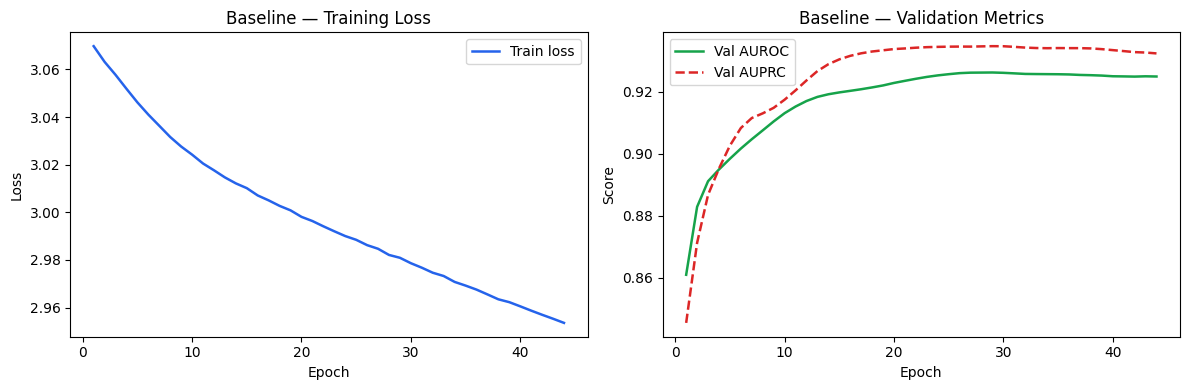


  Embedding shapes:
    disease: (17080, 128)
    drug: (6681, 128)
    effect: (990, 128)
    phenotype: (15311, 128)
    protein: (19059, 128)

  BLOCK 07 COMPLETE
  Objects now available:
    baseline_model
    baseline_embeddings
    baseline_results
    baseline_history_df
    -- shared utilities also defined here --
    sample_negative_edges_bipartite(...)
    bce_loss / bpr_loss / combined_loss
    evaluate_link_prediction(...)
    score_all_drugs_for_disease(...)


In [ ]:
# Model - Baseline Heterogeneous GNN / Train

# Guards
assert "train_data"            in globals(), "Run Block 06 first."
assert "TARGET_EDGE_TRIPLET"   in globals(), "Run Block 06 first."
assert "all_positive_pairs"    in globals(), "Run Block 06 first."
assert "num_nodes_dict"        in globals(), "Run Block 04 first."

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# Resolve graph and supervision edge
train_graph   = train_data.to(device)
SUP_EDGE_TYPE = TARGET_EDGE_TRIPLET
src_type, rel_type, dst_type = SUP_EDGE_TYPE

assert SUP_EDGE_TYPE in train_graph.edge_types, \
    f"{SUP_EDGE_TYPE} not found in train_graph.edge_types"

print(f"Supervision edge : {SUP_EDGE_TYPE}")
print(f"Node types       : {train_graph.node_types}")
print(f"Edge types       : {len(train_graph.edge_types)}")

# Move supervision tensors to device
def _to_device(name: str):
    g = globals()
    t = g.get(name)
    return t.to(device) if (t is not None and torch.is_tensor(t)) else t

val_pos_ei  = _to_device("val_pos_edge_label_index")
val_neg_ei  = _to_device("val_neg_edge_label_index")
test_pos_ei = _to_device("test_pos_edge_label_index")
test_neg_ei = _to_device("test_neg_edge_label_index")

# Build the complete forbidden set
_all_pos_parts = [train_graph[SUP_EDGE_TYPE].edge_index.detach().cpu()]
if val_pos_ei  is not None: _all_pos_parts.append(val_pos_ei.detach().cpu())
if test_pos_ei is not None: _all_pos_parts.append(test_pos_ei.detach().cpu())
_all_pos_cat = torch.cat(_all_pos_parts, dim=1)
all_positive_pairs = set(map(tuple, _all_pos_cat.t().tolist()))

num_drugs    = int(train_graph[src_type].num_nodes)
num_diseases = int(train_graph[dst_type].num_nodes)

print(f"\nTrain indication edges : {train_graph[SUP_EDGE_TYPE].edge_index.shape[1]:,}")
print(f"Drug nodes             : {num_drugs:,}")
print(f"Disease nodes          : {num_diseases:,}")
print(f"Known positive pairs   : {len(all_positive_pairs):,}")

# Shared utilities

def sample_negative_edges_bipartite(
    num_src: int,
    num_dst: int,
    forbidden_pairs: set,
    num_neg_samples: int,
    device=None,
) -> torch.Tensor:
    """
    Sample (drug, disease) pairs that are NOT in forbidden_pairs.

    Uses vectorised batch rejection sampling:
      - Draw 3× candidates at once, filter the forbidden ones
      - Repeat until enough are collected
    This is ~10× faster than drawing one pair at a time.

    Returns LongTensor of shape [2, num_neg_samples].
    """
    collected = set()
    rng = np.random.default_rng(SEED)

    while len(collected) < num_neg_samples:
        need = num_neg_samples - len(collected)
        srcs = rng.integers(0, num_src, need * 3).tolist()
        dsts = rng.integers(0, num_dst, need * 3).tolist()
        for s, d in zip(srcs, dsts):
            pair = (s, d)
            if pair not in forbidden_pairs and pair not in collected:
                collected.add(pair)
                if len(collected) >= num_neg_samples:
                    break

    tensor = torch.tensor(list(collected), dtype=torch.long).t().contiguous()
    return tensor.to(device) if device is not None else tensor


def bce_loss(pos_logits: torch.Tensor, neg_logits: torch.Tensor) -> torch.Tensor:
    """
    Binary cross-entropy loss.
    Treats link prediction as a yes/no classification problem per pair.
    Good at calibrating probabilities but does not directly optimise ranking.
    """
    logits = torch.cat([pos_logits, neg_logits])
    labels = torch.cat([
        torch.ones(pos_logits.size(0),  device=logits.device),
        torch.zeros(neg_logits.size(0), device=logits.device),
    ])
    return F.binary_cross_entropy_with_logits(logits, labels)


def bpr_loss(pos_logits: torch.Tensor, neg_logits: torch.Tensor) -> torch.Tensor:
    """
    Bayesian Personalised Ranking loss.
    For each positive edge, maximise the margin over a random negative.
    This directly optimises the ranking objective:
        pos_score should be higher than neg_score.

    Formula: -mean( log sigmoid( pos_score - neg_score ) )
    """
    n    = min(pos_logits.size(0), neg_logits.size(0))
    perm = torch.randperm(neg_logits.size(0), device=neg_logits.device)[:n]
    return -F.logsigmoid(pos_logits[:n] - neg_logits[perm]).mean()


def combined_loss(
    pos_logits: torch.Tensor,
    neg_logits: torch.Tensor,
    bce_weight: float = 0.5,
    bpr_weight: float = 0.5,
) -> torch.Tensor:
    """
    Weighted sum of BCE + BPR.
    BCE gives calibrated probabilities; BPR trains the ranking order directly.
    Both matter: BCE alone produces a good classifier but a poor ranker.
    """
    return (bce_weight * bce_loss(pos_logits, neg_logits) +
            bpr_weight * bpr_loss(pos_logits, neg_logits))


@torch.no_grad()
def evaluate_link_prediction(
    model: nn.Module,
    graph,
    pos_edge_index: torch.Tensor,
    neg_edge_index: torch.Tensor = None,
    edge_type: tuple = None,
    forbidden_pairs: set = None,
) -> dict:
    """
    Compute AUROC, AUPRC and score statistics for a pos/neg split.
    If neg_edge_index is None, fresh typed negatives are sampled.
    Returns a plain dict of metric_name -> float.
    """
    model.eval()
    if edge_type is None:
        edge_type = model.supervision_edge_type

    if neg_edge_index is None:
        neg_edge_index = sample_negative_edges_bipartite(
            num_src=int(graph[edge_type[0]].num_nodes),
            num_dst=int(graph[edge_type[2]].num_nodes),
            forbidden_pairs=forbidden_pairs or set(),
            num_neg_samples=pos_edge_index.size(1),
            device=pos_edge_index.device,
        )

    z_dict      = model.encode(graph)
    pos_logits  = model.decode(z_dict, pos_edge_index, edge_type=edge_type)
    neg_logits  = model.decode(z_dict, neg_edge_index, edge_type=edge_type)
    pos_probs   = torch.sigmoid(pos_logits)
    neg_probs   = torch.sigmoid(neg_logits)

    y_true  = torch.cat([torch.ones(pos_logits.size(0)),
                         torch.zeros(neg_logits.size(0))]).cpu().numpy()
    y_score = torch.cat([pos_probs, neg_probs]).detach().cpu().numpy()

    return {
        "auroc":          float(roc_auc_score(y_true, y_score)),
        "auprc":          float(average_precision_score(y_true, y_score)),
        "pos_mean_score": float(pos_probs.mean().item()),
        "neg_mean_score": float(neg_probs.mean().item()),
        # score_gap tells us how well-separated pos and neg distributions are.
        "score_gap":      float((pos_probs - neg_probs).mean().item()),
        "n_pos":          int(pos_edge_index.size(1)),
        "n_neg":          int(neg_edge_index.size(1)),
    }


@torch.no_grad()
def score_all_drugs_for_disease(
    model: nn.Module,
    graph,
    disease_idx: int,
    exclude_known_train: bool = True,
    top_k: int = 100,
    model_name: str = "model",
) -> pd.DataFrame:
    """
    Score every drug against a single query disease and return the top_k.

    Parameters
    ----------
    model               : any trained link predictor (Baseline or HGT)
    graph               : HeteroData — the training message-passing graph
    disease_idx         : integer index of the target disease node
    exclude_known_train : mask out drugs that were positive in training
    top_k               : how many candidates to return
    model_name          : column name prefix for the score column

    Returns
    -------
    pd.DataFrame with columns [drug_idx, {model_name}_score], sorted descending.
    """
    model.eval()
    s_type, _, d_type = model.supervision_edge_type
    mdev = next(model.parameters()).device

    num_drugs_   = int(graph[s_type].num_nodes)
    all_drug_idx = torch.arange(num_drugs_, device=mdev)
    disease_col  = torch.full((num_drugs_,), disease_idx, dtype=torch.long, device=mdev)
    cand_ei      = torch.stack([all_drug_idx, disease_col], dim=0)

    z_dict  = model.encode(graph)
    logits  = model.decode(z_dict, cand_ei, edge_type=model.supervision_edge_type)
    scores  = torch.sigmoid(logits).detach().cpu().clone()

    if exclude_known_train:
        # Suppress drugs already known to treat this disease in training
        train_ei  = graph[model.supervision_edge_type].edge_index.cpu()
        known_mask = train_ei[1] == disease_idx
        known_drugs = train_ei[0][known_mask]
        scores[known_drugs] = -1.0

    actual_k = min(top_k, num_drugs_)
    top_scores, top_idx = torch.topk(scores, k=actual_k)

    return pd.DataFrame({
        "drug_idx":            top_idx.numpy(),
        f"{model_name}_score": top_scores.numpy(),
    })


# Model definition

class HeteroEmbeddingEncoder(nn.Module):
    """
    One learnable nn.Embedding table per node type.
    If we set node features to x = [0, 1, 2, ...] and use Linear(1, H),
    every node's initial representation is W * index + b.  That places all
    nodes on a single line in H-dimensional space — drug node 5 is just
    "5 × W + b".  The GNN propagates along that line, so all disease
    embeddings end up near each other and every disease query returns the
    same ranked drug list.

    With nn.Embedding, node i gets column i of a freely-learnable matrix.
    Each node starts at an independent point; the GNN can then pull them
    into meaningful neighbourhoods based on graph structure.

    Xavier initialisation spreads the initial embeddings uniformly on the
    unit sphere, preventing collapse at epoch 0.
    """
    def __init__(self, num_nodes_per_type: dict, hidden_channels: int):
        super().__init__()
        self.embeddings = nn.ModuleDict()
        for node_type, n_nodes in num_nodes_per_type.items():
            emb = nn.Embedding(n_nodes, hidden_channels)
            nn.init.xavier_uniform_(emb.weight.data.unsqueeze(0)).squeeze(0)
            self.embeddings[node_type] = emb

    def forward(self, data) -> dict:
        """Return {node_type: FloatTensor[N, hidden_channels]}."""
        dev = next(self.parameters()).device
        return {
            nt: emb(torch.arange(int(data[nt].num_nodes), device=dev))
            for nt, emb in self.embeddings.items()
        }


class BaselineHeteroLinkPredictor(nn.Module):
    """
    Baseline heterogeneous GNN for drug–disease link prediction.

    Encoder: HeteroConv with SAGEConv per edge type
    SAGEConv aggregates a node's own features with a mean of its
    neighbours' features.  Using HeteroConv wraps one SAGEConv per
    edge type so the model learns separate aggregation weights for
    "drug targets protein" vs "disease associated with protein", etc.

    After each layer:
      1. LayerNorm stabilises activations across the heterogeneous graph
      2. GELU activation (smoother than ReLU, avoids dead neuron problem)
      3. Dropout regularises dense biological neighbourhoods
      4. Residual connection preserves the node's own identity

    Decoder: DistMult with L2-normalised embeddings
    score(drug d, disease x) = z_d · R · z_x
    where R = diag(rel_vector) and · is element-wise then summed.

    L2-normalise z_d and z_x before scoring:
      Without normalisation, the model can minimise loss simply by
      making ‖z‖ → ∞.  All normalised vectors live on the unit sphere,
      so the score is purely a function of angle — the geometry we
      actually want the model to learn.
    """
    def __init__(
        self,
        data,
        hidden_channels: int = 128,
        out_channels:    int = 128,
        num_layers:      int = 2,
        dropout:         float = 0.2,
        supervision_edge_type: tuple = None,
    ):
        super().__init__()
        self.supervision_edge_type = supervision_edge_type
        self.dropout_p = dropout
        src_t, _, dst_t = supervision_edge_type

        # One embedding table per node type
        num_nodes_map = {nt: int(data[nt].num_nodes) for nt in data.node_types}
        self.input_encoder = HeteroEmbeddingEncoder(num_nodes_map, hidden_channels)

        # Stack of HeteroConv layers with per-type LayerNorms
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(HeteroConv(
                {
                    et: SAGEConv(
                        in_channels=(-1, -1),
                        out_channels=hidden_channels,
                        normalize=True,          # L2-normalise aggregated vectors
                        root_weight=True,
                        bias=True,
                    )
                    for et in data.edge_types
                },
                aggr="mean",
            ))
            self.norms.append(nn.ModuleDict(
                {nt: nn.LayerNorm(hidden_channels) for nt in data.node_types}
            ))

        self.dropout    = nn.Dropout(p=dropout)
        # Per-node-type output projection to the scoring space
        self.output_proj = nn.ModuleDict(
            {nt: nn.Linear(hidden_channels, out_channels) for nt in data.node_types}
        )
        # DistMult relation vector: one scalar weight per output dimension
        self.rel_vector = nn.Parameter(torch.empty(out_channels))
        nn.init.normal_(self.rel_vector, std=1.0 / out_channels ** 0.5)

    def encode(self, data) -> dict:
        """
        Run GNN encoder. Returns {node_type: FloatTensor[N, out_channels]}
        with drug and disease embeddings L2-normalised.
        """
        x_dict = self.input_encoder(data)

        for conv, norm_dict in zip(self.convs, self.norms):
            x_new = conv(x_dict, data.edge_index_dict)
            x_dict = {
                nt: norm_dict[nt](x_new.get(nt, x_dict[nt]) + x_dict[nt])
                for nt in x_dict
            }
            x_dict = {nt: F.gelu(x)           for nt, x in x_dict.items()}
            x_dict = {nt: self.dropout(x)      for nt, x in x_dict.items()}

        z_dict = {nt: self.output_proj[nt](x) for nt, x in x_dict.items()}

        s, _, d = self.supervision_edge_type
        z_dict[s] = F.normalize(z_dict[s], p=2, dim=-1)
        z_dict[d] = F.normalize(z_dict[d], p=2, dim=-1)
        return z_dict

    def decode(self, z_dict: dict, edge_index: torch.Tensor,
               edge_type: tuple = None) -> torch.Tensor:
        """
        DistMult score for each (drug, disease) pair.
        score = sum( z_drug ⊙ rel_vector ⊙ z_disease )
        Returns raw logits of shape [num_edges].
        """
        if edge_type is None:
            edge_type = self.supervision_edge_type
        s, _, d = edge_type
        z_s = z_dict[s][edge_index[0]]
        z_d = z_dict[d][edge_index[1]]
        return (z_s * self.rel_vector * z_d).sum(dim=-1)

    def forward(self, data, edge_index: torch.Tensor,
                edge_type: tuple = None) -> torch.Tensor:
        return self.decode(self.encode(data), edge_index, edge_type)

    def embedding_regularization(self, z_dict: dict,
                                  lambda_reg: float = 1e-4) -> torch.Tensor:
        """
        L2 penalty on drug and disease embedding norms.
        Keeps embeddings from growing unboundedly, which would
        destabilise the DistMult scores even after normalisation.
        """
        s, _, d = self.supervision_edge_type
        dev = self.rel_vector.device
        reg = (
            z_dict.get(s, torch.zeros(1, device=dev)).norm(2).pow(2) +
            z_dict.get(d, torch.zeros(1, device=dev)).norm(2).pow(2)
        )
        return lambda_reg * reg

# Training

def _train_epoch(
    model: nn.Module,
    graph,
    optimizer: torch.optim.Optimizer,
    neg_ratio:      int   = 5,
    grad_clip:      float = 1.0,
    bce_weight:     float = 0.5,
    bpr_weight:     float = 0.5,
    emb_reg_lambda: float = 1e-4,
) -> float:
    """
    One complete training step:
      1. Sample fresh typed negatives (neg_ratio × positives)
      2. Encode all nodes
      3. Score positive and negative pairs
      4. Compute combined BCE + BPR loss + embedding regularisation
      5. Backprop + gradient clip + optimiser update
    Returns the scalar training loss.
    """
    model.train()
    optimizer.zero_grad()

    et           = model.supervision_edge_type
    pos_ei       = graph[et].edge_index
    num_neg      = int(pos_ei.size(1) * neg_ratio)

    neg_ei = sample_negative_edges_bipartite(
        num_src=int(graph[et[0]].num_nodes),
        num_dst=int(graph[et[2]].num_nodes),
        forbidden_pairs=all_positive_pairs,
        num_neg_samples=num_neg,
        device=pos_ei.device,
    )

    z_dict     = model.encode(graph)
    pos_logits = model.decode(z_dict, pos_ei,  edge_type=et)
    neg_logits = model.decode(z_dict, neg_ei,  edge_type=et)

    loss = combined_loss(pos_logits, neg_logits, bce_weight, bpr_weight)
    loss = loss + model.embedding_regularization(z_dict, emb_reg_lambda)

    loss.backward()
    if grad_clip:
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()
    return float(loss.item())


# Hyperparameters
B_HIDDEN   = 128
B_OUT      = 128
B_LAYERS   = 2
B_DROPOUT  = 0.2
B_EPOCHS   = 150
B_PATIENCE = 15
B_NEG_RATIO = 5

# Instantiate
baseline_model = BaselineHeteroLinkPredictor(
    data=train_graph,
    hidden_channels=B_HIDDEN,
    out_channels=B_OUT,
    num_layers=B_LAYERS,
    dropout=B_DROPOUT,
    supervision_edge_type=SUP_EDGE_TYPE,
).to(device)

with torch.no_grad():
    baseline_model.eval()
    _ = baseline_model.encode(train_graph)

n_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"\n{'='*55}")
print(f"  BASELINE MODEL")
print(f"{'='*55}")
print(baseline_model)
print(f"\n  Trainable parameters : {n_params:,}")

# Optimiser + cosine LR schedule
b_optimizer = torch.optim.AdamW(
    baseline_model.parameters(), lr=1e-3, weight_decay=1e-4
)
b_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    b_optimizer, T_max=B_EPOCHS, eta_min=1e-5
)

# Training loop
b_history          = []
best_b_state       = None
best_b_epoch       = -1
best_b_val_auprc   = -np.inf
b_no_improve       = 0

print(f"\n  Training for up to {B_EPOCHS} epochs "
      f"(early stop patience = {B_PATIENCE}) ...")
print(f"  {'Epoch':>6}  {'Loss':>8}  {'LR':>9}  "
      f"{'Val AUROC':>10}  {'Val AUPRC':>10}  {'Score Gap':>10}")
print("  " + "-" * 62)

for epoch in range(1, B_EPOCHS + 1):
    train_loss = _train_epoch(
        baseline_model, train_graph, b_optimizer,
        neg_ratio=B_NEG_RATIO,
    )
    b_scheduler.step()

    row = {"epoch": epoch, "train_loss": train_loss,
           "lr": b_scheduler.get_last_lr()[0]}

    if val_pos_ei is not None:
        vm = evaluate_link_prediction(
            baseline_model, train_graph,
            val_pos_ei, val_neg_ei,
            edge_type=SUP_EDGE_TYPE,
            forbidden_pairs=all_positive_pairs,
        )
        row.update({f"val_{k}": v for k, v in vm.items()})

        if vm["auprc"] > best_b_val_auprc:
            best_b_val_auprc = vm["auprc"]
            best_b_state     = copy.deepcopy(baseline_model.state_dict())
            best_b_epoch     = epoch
            b_no_improve     = 0
        else:
            b_no_improve += 1
    else:
        if best_b_state is None:
            best_b_state = copy.deepcopy(baseline_model.state_dict())
            best_b_epoch = epoch

    b_history.append(row)

    if epoch == 1 or epoch % 10 == 0:
        lr_str  = f"{row['lr']:.2e}"
        if "val_auroc" in row:
            print(f"  {epoch:>6}  {train_loss:>8.4f}  {lr_str:>9}  "
                  f"{row['val_auroc']:>10.4f}  {row['val_auprc']:>10.4f}  "
                  f"{row['val_score_gap']:>10.4f}")
        else:
            print(f"  {epoch:>6}  {train_loss:>8.4f}  {lr_str:>9}")

    if val_pos_ei is not None and b_no_improve >= B_PATIENCE:
        print(f"\n  Early stopping at epoch {epoch}. "
              f"Best epoch: {best_b_epoch}.")
        break

# Restore the checkpoint that achieved the best val AUPRC
if best_b_state is not None:
    baseline_model.load_state_dict(best_b_state)
    print(f"\n  Best checkpoint restored: epoch {best_b_epoch}, "
          f"val AUPRC = {best_b_val_auprc:.4f}")

baseline_history_df = pd.DataFrame(b_history)


# Final evaluation
baseline_results = {}

for split_name, pos_ei, neg_ei in [
    ("val",  val_pos_ei,  val_neg_ei),
    ("test", test_pos_ei, test_neg_ei),
]:
    if pos_ei is not None:
        baseline_results[split_name] = evaluate_link_prediction(
            baseline_model, train_graph, pos_ei, neg_ei,
            edge_type=SUP_EDGE_TYPE, forbidden_pairs=all_positive_pairs,
        )

print(f"\n{'='*55}")
print(f"  BASELINE FINAL RESULTS")
print(f"{'='*55}")
for split_name, metrics in baseline_results.items():
    print(f"\n  [{split_name.upper()}]")
    for k, v in metrics.items():
        val_str = f"{v:.6f}" if isinstance(v, float) else str(v)
        print(f"    {k:<22} : {val_str}")


# Training curve plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(baseline_history_df["epoch"], baseline_history_df["train_loss"],
             color="#2563eb", linewidth=1.8, label="Train loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Baseline — Training Loss"); axes[0].legend()

if "val_auroc" in baseline_history_df.columns:
    axes[1].plot(baseline_history_df["epoch"], baseline_history_df["val_auroc"],
                 color="#16a34a", linewidth=1.8, label="Val AUROC")
    axes[1].plot(baseline_history_df["epoch"], baseline_history_df["val_auprc"],
                 color="#dc2626", linewidth=1.8, linestyle="--", label="Val AUPRC")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
    axes[1].set_title("Baseline — Validation Metrics"); axes[1].legend()

plt.tight_layout()
plt.savefig("/mnt/data/baseline_training_curves.png", dpi=180, bbox_inches="tight")
plt.show()


# Export embeddings
@torch.no_grad()
def get_node_embeddings(model: nn.Module, graph) -> dict:
    """Return {node_type: FloatTensor[N, D]} on CPU (detached)."""
    model.eval()
    return {k: v.detach().cpu() for k, v in model.encode(graph).items()}

baseline_embeddings = get_node_embeddings(baseline_model, train_graph)

print(f"\n  Embedding shapes:")
for nt, emb in baseline_embeddings.items():
    print(f"    {nt}: {tuple(emb.shape)}")


# Summary
print(f"\n{'='*55}")
print(f"  BLOCK 07 COMPLETE")
print(f"{'='*55}")
print("  Objects now available:")
print("    baseline_model")
print("    baseline_embeddings")
print("    baseline_results")
print("    baseline_history_df")
print("    -- shared utilities also defined here --")
print("    sample_negative_edges_bipartite(...)")
print("    bce_loss / bpr_loss / combined_loss")
print("    evaluate_link_prediction(...)")
print("    score_all_drugs_for_disease(...)")
print(f"{'='*55}")

## 8. Model : **Heterogeneous Graph Transformer (HGT).**

### Model / Train Block.

This block defines and trains the **Heterogeneous Graph Transformer (HGT)** model for the drug repurposing task. While Block 7 introduced the baseline heterogeneous GNN, this section uses a stronger attention-based architecture that can model different node types and edge types more explicitly.

The main idea behind HGT is that not all graph messages should be treated equally. In a biomedical knowledge graph, a message coming from a **protein**, **disease**, or **drug** may carry very different meaning, and HGT is designed to account for those differences through type-aware attention.


### Define the supervision setup

This block uses the same prediction task as the baseline model:

- **source node type:** `drug`
- **relation type:** `indication`
- **destination node type:** `disease`

That means the HGT model is also trained for **drug–disease link prediction**, making the comparison with the baseline model fair and consistent.

### HGT model architecture

The main model class in this block is `HGTLinkPredictor`.

Like the baseline model, it starts with the same **trainable node embedding encoder**, which creates one embedding table per node type. This keeps the comparison fair, since both models begin from the same kind of node representation.

The main difference is in the graph encoder.

#### HGT encoder

Instead of using GraphSAGE-style message passing, this model uses one or more **`HGTConv`** layers. These layers apply **type-aware multi-head attention**, which means the model can learn different attention patterns depending on:
- the source node type
- the edge type
- the destination node type

This is useful in a heterogeneous biomedical graph because a path like:

- **drug → protein**
  
may carry a different kind of signal than:

- **disease → phenotype**
- **protein → disease**

So rather than averaging all neighbor information in the same way, HGT learns how much attention to give to each type of message.

#### Residual connections and normalization

Each HGT layer is followed by:
- **attention dropout**
- **residual connections**
- **layer normalization**
- **GELU activation**
- **feature dropout**

These components help stabilize training and reduce overfitting. The residual connections are especially important because they help preserve earlier node information across layers instead of letting it wash out completely.

#### Output projections and decoder

After message passing, the model applies a separate output projection for each node type. This is done to preserve type-specific structure instead of forcing all node types through a single shared projection.

For scoring drug–disease candidate pairs, the block uses the same **DistMult-style decoder** as the baseline model. This is important because it isolates the comparison to the encoder: if performance changes, it is mainly due to switching from GraphSAGE-style convolution to HGT attention, not due to a different decoder.

The model also applies **L2 normalization** to the final drug and disease embeddings before scoring, again matching the baseline setup.

### Training procedure

The training flow is implemented in the helper function `_train_epoch_hgt(...)`.

In each epoch, the function:
1. computes the current node embeddings from the training graph
2. samples negative drug–disease pairs
3. scores positive training indication edges
4. scores sampled negative edges
5. computes the combined loss
6. adds embedding regularization
7. backpropagates and updates the model parameters

The loss setup is intentionally kept the same as in the baseline block so that the training comparison remains fair.

### Hyperparameters

This block defines a fixed HGT configuration using hyperparameters such as:
- hidden dimension size
- output embedding size
- number of attention heads
- number of HGT layers
- feature dropout
- attention dropout
- number of epochs
- early stopping patience
- negative sampling ratio


### Model initialization and warm-up

After instantiating the HGT model, the block runs a warm-up encoding pass before counting parameters or starting optimization. This is necessary because `HGTConv` uses lazy initialization, so some parameter shapes are only finalized once the model sees an actual input graph.

### Optimization and learning-rate scheduling

The optimizer used is **AdamW**, which is also consistent with the baseline block. A **cosine annealing learning-rate scheduler** is applied so the learning rate gradually decreases during training.

This setup helps training stay stable while still allowing the model to make larger updates earlier in optimization.

### Training loop and early stopping

The main training loop runs for up to a fixed maximum number of epochs. In each epoch, the notebook:
- trains the HGT model for one epoch
- evaluates it on the validation set
- records the training loss and validation metrics
- tracks the best checkpoint based on **validation AUPRC**

The block also uses **early stopping**. If validation AUPRC does not improve for a specified number of epochs, training stops early and the best-performing checkpoint is restored.


### Final evaluation

Once training is complete, the best saved HGT checkpoint is reloaded and evaluated on the:
- validation split
- test split

The resulting metrics are stored in `hgt_results`. These results are later compared against the baseline model to see whether the attention-based architecture provides a real improvement.

### Training-curve visualization

To make the optimization behavior easier to inspect, the block plots:
- the **training loss** across epochs
- the **validation AUROC**
- the **validation AUPRC**

Device : cuda
Supervision edge : ('drug', 'indication', 'disease')
Node types       : ['disease', 'drug', 'effect', 'phenotype', 'protein']
Edge types       : 13

  HGT MODEL
HGTLinkPredictor(
  (input_encoder): HeteroEmbeddingEncoder(
    (embeddings): ModuleDict(
      (disease): Embedding(17080, 128)
      (drug): Embedding(6681, 128)
      (effect): Embedding(990, 128)
      (phenotype): Embedding(15311, 128)
      (protein): Embedding(19059, 128)
    )
  )
  (convs): ModuleList(
    (0): HGTConv(-1, 128, heads=4)
  )
  (norms): ModuleList(
    (0): ModuleDict(
      (disease): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (drug): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (effect): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (phenotype): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (protein): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (attn_dropout): Drop

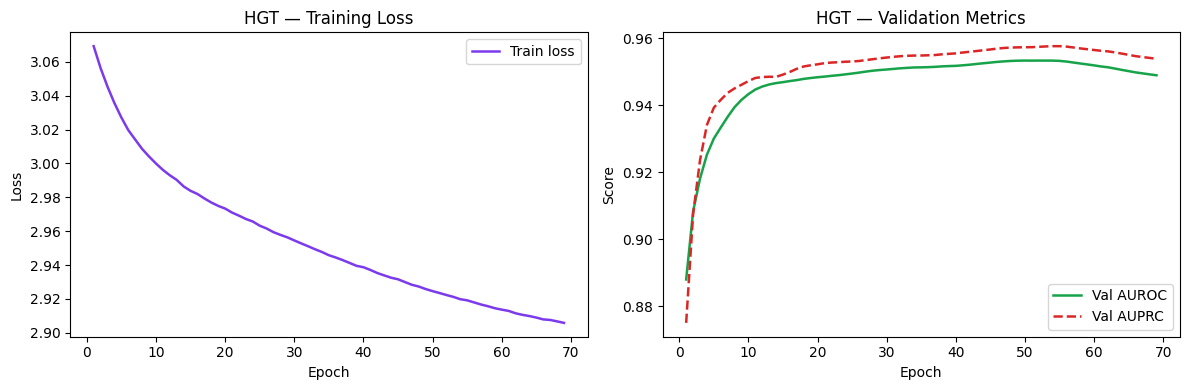


  Embedding shapes:
    disease: (17080, 128)
    drug: (6681, 128)
    effect: (990, 128)
    phenotype: (15311, 128)
    protein: (19059, 128)

  BLOCK 08 COMPLETE
  Objects now available:
    hgt_model
    hgt_embeddings
    hgt_results
    hgt_history_df


In [ ]:
# Model - Heterogeneous Graph Transformer (HGT) / Train

# Guards
assert "train_data"                        in globals(), "Run Block 06 first."
assert "TARGET_EDGE_TRIPLET"               in globals(), "Run Block 06 first."
assert "all_positive_pairs"               in globals(), "Run Block 06 first."
assert "HeteroEmbeddingEncoder"           in globals(), "Run Block 07 first."
assert "combined_loss"                    in globals(), "Run Block 07 first."
assert "evaluate_link_prediction"         in globals(), "Run Block 07 first."
assert "sample_negative_edges_bipartite"  in globals(), "Run Block 07 first."

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# Resolve graph and supervision edge
train_graph   = train_data.to(device)
SUP_EDGE_TYPE = TARGET_EDGE_TRIPLET
src_type, rel_type, dst_type = SUP_EDGE_TYPE

# Supervision tensors
def _to_device(name: str):
    g = globals()
    t = g.get(name)
    return t.to(device) if (t is not None and torch.is_tensor(t)) else t

val_pos_ei  = _to_device("val_pos_edge_label_index")
val_neg_ei  = _to_device("val_neg_edge_label_index")
test_pos_ei = _to_device("test_pos_edge_label_index")
test_neg_ei = _to_device("test_neg_edge_label_index")

print(f"Supervision edge : {SUP_EDGE_TYPE}")
print(f"Node types       : {train_graph.node_types}")
print(f"Edge types       : {len(train_graph.edge_types)}")


# HGT model definition

class HGTLinkPredictor(nn.Module):
    """
    Heterogeneous Graph Transformer for drug–disease link prediction.

    Encoder: HGTConv (type-aware multi-head attention)

    Each HGT layer computes, for every node v of type τ(v):

        h_v^{l+1} = Σ_{u ∈ N(v)} Attention(τ(u), φ(u,v), τ(v)) · Message(u)

    The attention weight is a function of source type, edge type, and
    target type — not just of the edge features.  This lets the model
    weight "protein → disease" messages differently from
    "drug → disease" messages, which matches biological intuition.

    Key hyperparameters:
      hidden_channels: must be divisible by num_heads
                       (each head gets hidden_channels // num_heads dims)
      num_heads:       4 heads × 32 dims = 128 hidden is a good default
      num_layers:      1 (see module docstring on over-smoothing)
      attn_dropout:    randomly zeroes attention weights during training,
                       forcing the model to rely on multiple neighbour types
                       rather than always attending to the same path

    Decoder: same DistMult + L2 normalisation as Baseline

    Keeping the decoder identical lets us directly compare encoders.
    Any difference in performance is attributable purely to the GNN.
    """

    def __init__(
        self,
        data,
        hidden_channels: int   = 128,
        out_channels:    int   = 128,
        num_heads:       int   = 4,
        num_layers:      int   = 1,
        dropout:         float = 0.2,
        attn_dropout:    float = 0.1,
        supervision_edge_type: tuple = None,
    ):
        super().__init__()
        self.supervision_edge_type = supervision_edge_type
        self.dropout_p      = dropout
        self.attn_dropout_p = attn_dropout
        src_t, _, dst_t = supervision_edge_type

        assert hidden_channels % num_heads == 0, (
            f"hidden_channels ({hidden_channels}) must be divisible by "
            f"num_heads ({num_heads})."
        )

        num_nodes_map = {nt: int(data[nt].num_nodes) for nt in data.node_types}
        self.input_encoder = HeteroEmbeddingEncoder(num_nodes_map, hidden_channels)

        # HGT convolution layers.
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(HGTConv(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                metadata=data.metadata(),   # (node_types, edge_types)
                heads=num_heads,
            ))
            self.norms.append(nn.ModuleDict(
                {nt: nn.LayerNorm(hidden_channels) for nt in data.node_types}
            ))

        self.dropout      = nn.Dropout(p=dropout)
        # Attention dropout: applied to the values that HGT returns before the residual add.
        self.attn_dropout = nn.Dropout(p=attn_dropout)

        # Separate output projection per node type
        self.output_proj = nn.ModuleDict(
            {nt: nn.Linear(hidden_channels, out_channels) for nt in data.node_types}
        )
        # DistMult relation vector
        self.rel_vector = nn.Parameter(torch.empty(out_channels))
        nn.init.normal_(self.rel_vector, std=1.0 / out_channels ** 0.5)

    def encode(self, data) -> dict:
        """
        HGT forward pass.
        Returns {node_type: FloatTensor[N, out_channels]}
        with drug and disease embeddings L2-normalised.
        """
        x_dict = self.input_encoder(data)

        for conv, norm_dict in zip(self.convs, self.norms):
            x_new = conv(x_dict, data.edge_index_dict)

            x_dict = {}
            for nt in norm_dict:
                new_val = x_new.get(nt)
                if new_val is not None:
                    # Apply attention dropout to the new information before combining with the residual.
                    new_val = self.attn_dropout(new_val)
                    x_dict[nt] = norm_dict[nt](new_val + self.input_encoder.embeddings[nt](
                        torch.arange(new_val.size(0), device=new_val.device)
                    ) if False else new_val + self._prev_x.get(nt, new_val))
                else:
                    x_dict[nt] = self._prev_x.get(nt, torch.zeros_like(
                        next(iter(self._prev_x.values()))
                    ))

            x_dict = {nt: F.gelu(norm_dict[nt](x)) for nt, x in x_dict.items()}
            x_dict = {nt: self.dropout(x)           for nt, x in x_dict.items()}

        z_dict = {nt: self.output_proj[nt](x) for nt, x in x_dict.items()}

        # L2-normalise drug and disease embeddings — same fix as Baseline
        s, _, d = self.supervision_edge_type
        z_dict[s] = F.normalize(z_dict[s], p=2, dim=-1)
        z_dict[d] = F.normalize(z_dict[d], p=2, dim=-1)
        return z_dict

    def decode(self, z_dict: dict, edge_index: torch.Tensor,
               edge_type: tuple = None) -> torch.Tensor:
        """DistMult score: sum(z_drug ⊙ rel_vector ⊙ z_disease)."""
        if edge_type is None:
            edge_type = self.supervision_edge_type
        s, _, d = edge_type
        return (z_dict[s][edge_index[0]] * self.rel_vector *
                z_dict[d][edge_index[1]]).sum(dim=-1)

    def forward(self, data, edge_index: torch.Tensor,
                edge_type: tuple = None) -> torch.Tensor:
        return self.decode(self.encode(data), edge_index, edge_type)

    def embedding_regularization(self, z_dict: dict,
                                  lambda_reg: float = 1e-4) -> torch.Tensor:
        s, _, d = self.supervision_edge_type
        dev = self.rel_vector.device
        reg = (
            z_dict.get(s, torch.zeros(1, device=dev)).norm(2).pow(2) +
            z_dict.get(d, torch.zeros(1, device=dev)).norm(2).pow(2)
        )
        return lambda_reg * reg

    # Internal storage used by encode() to carry the residual across layers
    _prev_x: dict = {}


class HGTLinkPredictor(nn.Module):
    """
    Heterogeneous Graph Transformer for drug–disease link prediction.
    See module-level docstring above for full explanation.
    """

    def __init__(
        self,
        data,
        hidden_channels: int   = 128,
        out_channels:    int   = 128,
        num_heads:       int   = 4,
        num_layers:      int   = 1,
        dropout:         float = 0.2,
        attn_dropout:    float = 0.1,
        supervision_edge_type: tuple = None,
    ):
        super().__init__()
        self.supervision_edge_type = supervision_edge_type
        self.dropout_p      = dropout
        self.attn_dropout_p = attn_dropout

        assert hidden_channels % num_heads == 0, (
            f"hidden_channels ({hidden_channels}) must be divisible by "
            f"num_heads ({num_heads})."
        )

        num_nodes_map = {nt: int(data[nt].num_nodes) for nt in data.node_types}
        self.input_encoder = HeteroEmbeddingEncoder(num_nodes_map, hidden_channels)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(HGTConv(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                metadata=data.metadata(),
                heads=num_heads,
            ))
            self.norms.append(nn.ModuleDict(
                {nt: nn.LayerNorm(hidden_channels) for nt in data.node_types}
            ))

        self.dropout      = nn.Dropout(p=dropout)
        self.attn_dropout = nn.Dropout(p=attn_dropout)
        self.output_proj  = nn.ModuleDict(
            {nt: nn.Linear(hidden_channels, out_channels) for nt in data.node_types}
        )
        self.rel_vector = nn.Parameter(torch.empty(out_channels))
        nn.init.normal_(self.rel_vector, std=1.0 / out_channels ** 0.5)

    def encode(self, data) -> dict:
        """
        HGT forward pass with residual connections + attention dropout.
        Returns {node_type: L2-normalised FloatTensor[N, out_channels]}.
        """
        x_dict = self.input_encoder(data)

        for conv, norm_dict in zip(self.convs, self.norms):
            x_new = conv(x_dict, data.edge_index_dict)

            # Build next layer's input:
            # For node types that received messages: attn_dropout + residual + norm
            # For node types with no incoming messages: keep current embedding
            next_x = {}
            for nt in x_dict:
                if nt in x_new and x_new[nt] is not None:
                    updated = self.attn_dropout(x_new[nt]) + x_dict[nt]
                    next_x[nt] = norm_dict[nt](updated)
                else:
                    next_x[nt] = norm_dict[nt](x_dict[nt])

            x_dict = {nt: F.gelu(x)      for nt, x in next_x.items()}
            x_dict = {nt: self.dropout(x) for nt, x in x_dict.items()}

        z_dict = {nt: self.output_proj[nt](x) for nt, x in x_dict.items()}

        # Unit-sphere projection for drug and disease embeddings
        s, _, d = self.supervision_edge_type
        z_dict[s] = F.normalize(z_dict[s], p=2, dim=-1)
        z_dict[d] = F.normalize(z_dict[d], p=2, dim=-1)
        return z_dict

    def decode(self, z_dict: dict, edge_index: torch.Tensor,
               edge_type: tuple = None) -> torch.Tensor:
        if edge_type is None:
            edge_type = self.supervision_edge_type
        s, _, d = edge_type
        return (z_dict[s][edge_index[0]] * self.rel_vector *
                z_dict[d][edge_index[1]]).sum(dim=-1)

    def forward(self, data, edge_index: torch.Tensor,
                edge_type: tuple = None) -> torch.Tensor:
        return self.decode(self.encode(data), edge_index, edge_type)

    def embedding_regularization(self, z_dict: dict,
                                  lambda_reg: float = 1e-4) -> torch.Tensor:
        s, _, d = self.supervision_edge_type
        dev = self.rel_vector.device
        reg = (
            z_dict.get(s, torch.zeros(1, device=dev)).norm(2).pow(2) +
            z_dict.get(d, torch.zeros(1, device=dev)).norm(2).pow(2)
        )
        return lambda_reg * reg

# Training

def _train_epoch_hgt(
    model: nn.Module,
    graph,
    optimizer: torch.optim.Optimizer,
    neg_ratio:      int   = 5,
    grad_clip:      float = 1.0,
    bce_weight:     float = 0.5,
    bpr_weight:     float = 0.5,
    emb_reg_lambda: float = 1e-4,
) -> float:
    """One HGT training epoch — identical flow to Baseline."""
    model.train()
    optimizer.zero_grad()

    et      = model.supervision_edge_type
    pos_ei  = graph[et].edge_index
    num_neg = int(pos_ei.size(1) * neg_ratio)

    neg_ei = sample_negative_edges_bipartite(
        num_src=int(graph[et[0]].num_nodes),
        num_dst=int(graph[et[2]].num_nodes),
        forbidden_pairs=all_positive_pairs,
        num_neg_samples=num_neg,
        device=pos_ei.device,
    )

    z_dict     = model.encode(graph)
    pos_logits = model.decode(z_dict, pos_ei,  edge_type=et)
    neg_logits = model.decode(z_dict, neg_ei,  edge_type=et)

    loss = combined_loss(pos_logits, neg_logits, bce_weight, bpr_weight)
    loss = loss + model.embedding_regularization(z_dict, emb_reg_lambda)

    loss.backward()
    if grad_clip:
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()
    return float(loss.item())


# Hyperparameters
H_HIDDEN      = 128
H_OUT         = 128
H_HEADS       = 4       # 128 / 4 = 32 dims per head
H_LAYERS      = 1
H_DROPOUT     = 0.2
H_ATTN_DROP   = 0.1     # attention-weight dropout, unique to HGT
H_EPOCHS      = 150
H_PATIENCE    = 15
H_NEG_RATIO   = 5

# Instantiate
hgt_model = HGTLinkPredictor(
    data=train_graph,
    hidden_channels=H_HIDDEN,
    out_channels=H_OUT,
    num_heads=H_HEADS,
    num_layers=H_LAYERS,
    dropout=H_DROPOUT,
    attn_dropout=H_ATTN_DROP,
    supervision_edge_type=SUP_EDGE_TYPE,
).to(device)

# HGTConv is also a lazy module
with torch.no_grad():
    hgt_model.eval()
    _ = hgt_model.encode(train_graph)

n_params = sum(p.numel() for p in hgt_model.parameters() if p.requires_grad)
print(f"\n{'='*55}")
print(f"  HGT MODEL")
print(f"{'='*55}")
print(hgt_model)
print(f"\n  Trainable parameters : {n_params:,}")

# Optimiser + scheduler
hgt_optimizer = torch.optim.AdamW(
    hgt_model.parameters(), lr=1e-3, weight_decay=1e-4
)
hgt_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    hgt_optimizer, T_max=H_EPOCHS, eta_min=1e-5
)

# Training loop
hgt_history        = []
best_hgt_state     = None
best_hgt_epoch     = -1
best_hgt_val_auprc = -np.inf
hgt_no_improve     = 0

print(f"\n  Training for up to {H_EPOCHS} epochs "
      f"(early stop patience = {H_PATIENCE}) ...")
print(f"  {'Epoch':>6}  {'Loss':>8}  {'LR':>9}  "
      f"{'Val AUROC':>10}  {'Val AUPRC':>10}  {'Score Gap':>10}")
print("  " + "-" * 62)

for epoch in range(1, H_EPOCHS + 1):
    train_loss = _train_epoch_hgt(
        hgt_model, train_graph, hgt_optimizer,
        neg_ratio=H_NEG_RATIO,
    )
    hgt_scheduler.step()

    row = {"epoch": epoch, "train_loss": train_loss,
           "lr": hgt_scheduler.get_last_lr()[0]}

    if val_pos_ei is not None:
        vm = evaluate_link_prediction(
            hgt_model, train_graph,
            val_pos_ei, val_neg_ei,
            edge_type=SUP_EDGE_TYPE,
            forbidden_pairs=all_positive_pairs,
        )
        row.update({f"val_{k}": v for k, v in vm.items()})

        if vm["auprc"] > best_hgt_val_auprc:
            best_hgt_val_auprc = vm["auprc"]
            best_hgt_state     = copy.deepcopy(hgt_model.state_dict())
            best_hgt_epoch     = epoch
            hgt_no_improve     = 0
        else:
            hgt_no_improve += 1
    else:
        if best_hgt_state is None:
            best_hgt_state = copy.deepcopy(hgt_model.state_dict())
            best_hgt_epoch = epoch

    hgt_history.append(row)

    if epoch == 1 or epoch % 10 == 0:
        lr_str = f"{row['lr']:.2e}"
        if "val_auroc" in row:
            print(f"  {epoch:>6}  {train_loss:>8.4f}  {lr_str:>9}  "
                  f"{row['val_auroc']:>10.4f}  {row['val_auprc']:>10.4f}  "
                  f"{row['val_score_gap']:>10.4f}")
        else:
            print(f"  {epoch:>6}  {train_loss:>8.4f}  {lr_str:>9}")

    if val_pos_ei is not None and hgt_no_improve >= H_PATIENCE:
        print(f"\n  Early stopping at epoch {epoch}. "
              f"Best epoch: {best_hgt_epoch}.")
        break

if best_hgt_state is not None:
    hgt_model.load_state_dict(best_hgt_state)
    print(f"\n  Best checkpoint restored: epoch {best_hgt_epoch}, "
          f"val AUPRC = {best_hgt_val_auprc:.4f}")

hgt_history_df = pd.DataFrame(hgt_history)


# Final evaluation
hgt_results = {}

for split_name, pos_ei, neg_ei in [
    ("val",  val_pos_ei,  val_neg_ei),
    ("test", test_pos_ei, test_neg_ei),
]:
    if pos_ei is not None:
        hgt_results[split_name] = evaluate_link_prediction(
            hgt_model, train_graph, pos_ei, neg_ei,
            edge_type=SUP_EDGE_TYPE, forbidden_pairs=all_positive_pairs,
        )

print(f"\n{'='*55}")
print(f"  HGT FINAL RESULTS")
print(f"{'='*55}")
for split_name, metrics in hgt_results.items():
    print(f"\n  [{split_name.upper()}]")
    for k, v in metrics.items():
        val_str = f"{v:.6f}" if isinstance(v, float) else str(v)
        print(f"    {k:<22} : {val_str}")


# Training curve plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hgt_history_df["epoch"], hgt_history_df["train_loss"],
             color="#7c3aed", linewidth=1.8, label="Train loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("HGT — Training Loss"); axes[0].legend()

if "val_auroc" in hgt_history_df.columns:
    axes[1].plot(hgt_history_df["epoch"], hgt_history_df["val_auroc"],
                 color="#16a34a", linewidth=1.8, label="Val AUROC")
    axes[1].plot(hgt_history_df["epoch"], hgt_history_df["val_auprc"],
                 color="#dc2626", linewidth=1.8, linestyle="--", label="Val AUPRC")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
    axes[1].set_title("HGT — Validation Metrics"); axes[1].legend()

plt.tight_layout()
plt.savefig("/mnt/data/hgt_training_curves.png", dpi=180, bbox_inches="tight")
plt.show()


# Export embeddings
@torch.no_grad()
def get_hgt_embeddings(model: nn.Module, graph) -> dict:
    """Return {node_type: FloatTensor[N, D]} on CPU."""
    model.eval()
    return {k: v.detach().cpu() for k, v in model.encode(graph).items()}

hgt_embeddings = get_hgt_embeddings(hgt_model, train_graph)

print(f"\n  Embedding shapes:")
for nt, emb in hgt_embeddings.items():
    print(f"    {nt}: {tuple(emb.shape)}")


# Summary
print(f"\n{'='*55}")
print(f"  BLOCK 08 COMPLETE")
print(f"{'='*55}")
print("  Objects now available:")
print("    hgt_model")
print("    hgt_embeddings")
print("    hgt_results")
print("    hgt_history_df")
print(f"{'='*55}")